
# 🧠 Keras Transfer Learning ResNet50 - Classificació

---


## 🎯 Objectius

* Aquest notebook pretén mostrar un exemple de Transfer Learning amb Keras
* La tasca consisteix a tranferir el coneixment d'un model ResNet50 entrenat amb ImageNet a un model capaç d'identificar imatges del conjunt de dades Intel Image Classification (6 classes)


## 📦 Datasets

En aquest notebook t'utilitza el model ResNet50 entrenat amb el dataset [ImageNet](https://www.image-net.org/) (conté 1.2 milions d'imatges de 1.000 classes diferents).
Volem classificar les imatges del dataset [Intel Image Classification](https://www.kaggle.com/datasets/puneet6060/intel-image-classification). Conjunt de dades que conté prop de 25.000 imatges de 150x150 ditribuides en 6 categories/classes ('buildings' -> 0, 'forest' -> 1, 'glacier' -> 2, 'mountain' -> 3, 'sea' -> 4, 'street' -> 5)
Les dads s'extreurà de la plataforma Kaggle, però inicialiment va ser publicada n https://datahack.analyticsvidhya.com by Intel to host a Image classification Challenge.

- `seg_train/seg_train/<classe>`
- `seg_test/seg_test/<classe>`
- `seg_pred`
* seg_train: Directori més important per realitzar el train. Hi ha una subcarpeta per categoria.
* seg_test: Directori amb imatges de test . També té una subcarpeta per categoria.
* seg_pred:Directori sense etiquetes. serveix per provar el model amb imatges noves si es volen simular predicions reals.

In [ ]:
#!pip install tensorflow


## 🟦 0. Descàrrega del dataset de Kaggle

Descàrreguem el dataset de Kaggle, mitjançant el client de kaggle i API Token de la plataforma

In [ ]:
#pip install kaggle
from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

!kaggle datasets list -s intel-image-classification

ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  ------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
puneet6060/intel-image-classification                           Intel Image Classification                          363152213  2019-01-30 09:22:58.647000         178329       1652  0.75             
kkhandekar/image-dataset                                        Image_Dataset                                       179306148  2020-06-28 22:44:13.580000           2613         30  0.8125           
utkarshsaxenadn/intel-image-classifier-resblockcustom-model     Intel Image Classifier - ResBlock(Custom Model)        285531  2022-10-02 02:48:22.307000             52          8  1.0              
moham

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
 95% 330M/346M [00:05<00:00, 41.8MB/s]
100% 346M/346M [00:05<00:00, 61.3MB/s]


In [ ]:
!ls /content/seg_train/seg_train/

buildings  forest  glacier  mountain  sea  street


## 🟦 0. Import Classes

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
GPU available: []


## 🟦 1. Load Dataset

ResNet50 espera entrades **224×224×3**, així que cal redimensionar.

In [ ]:
DATA_ROOT = "/content"

train_dir = DATA_ROOT + "/seg_train/seg_train"
test_dir  = DATA_ROOT + "/seg_test/seg_test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# Carreguem el TRAIN
# No obtenim un array normal. Obtenim un objecte del tipus tf.data.Dataset.
# Objecte que funciona com una cinta.
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

#Carreguem el VALIDATE
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

#Carreguem el TEST
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names, "| num_classes:", num_classes)

Found 14034 files belonging to 6 classes.
Using 11228 files for training.
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.
Found 3000 files belonging to 6 classes.
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street'] | num_classes: 6


In [ ]:
#Li indiquem a Tensorflow que decideixi automàticament quants recursos utilitzar.
AUTOTUNE = tf.data.AUTOTUNE

#Aquest codi carregaria les imatges a cache. O sigui a memòria RAM
#train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
#val_ds   = val_ds.cache().prefetch(AUTOTUNE)
#test_ds  = test_ds.cache().prefetch(AUTOTUNE)

#Fem un shuffle perquè el model vegi les imatges barrejades i no primer les de "forest", llavors les de "sea", etc...
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

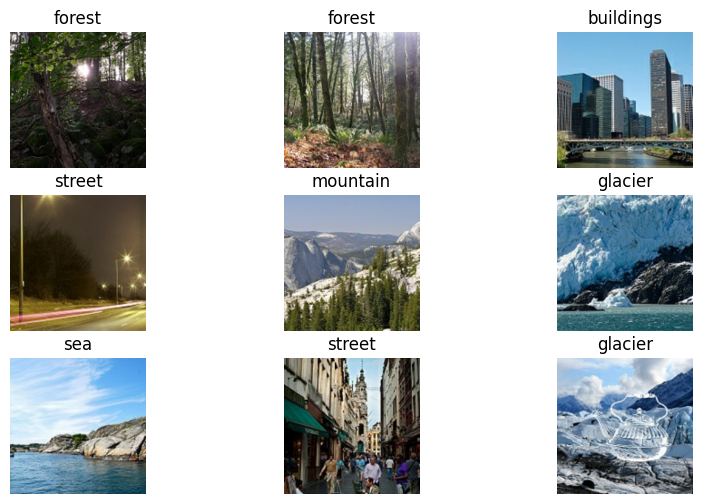

In [ ]:
plt.figure(figsize=(10, 6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.show()

## 🟦 2. Model ResNet50


In [ ]:
from tensorflow.keras.applications.resnet50 import preprocess_input

# Preparem una capa de Data Augmentation.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

#base_model.summary()


70557696/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step

KeyboardInterrupt: 

### Estratègia 1: Feature Extraction
- Carreguem ResNet50 amb pesos ImageNet (`weights='imagenet'`)
- Eliminem el top (`include_top=False`) per usar-la com a extractor de característiques
- **Congelem** la base (`trainable=False`) i entrenem només la capçalera nova



In [ ]:
base_model.trainable = False  # FEATURE EXTRACTION (congelat)


inputs = layers.Input(shape=(224, 224, 3), name="input")
x = data_augmentation(inputs)
x = preprocess_input(x)  # preprocess específic de ResNet50 (ImageNet)

# Important: training=False per evitar que BatchNorm de la base s'actualitzi mentre està congelada
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D(name="pool_avg")(x)
x = layers.Dropout(0.3, name="dropout_30")(x)
outputs = layers.Dense(num_classes, activation="softmax", name="classifier")(x)

model = Model(inputs, outputs, name="ResNet50_transfer_fe")
model.summary()

In [ ]:
# Potser el learning_rate estaria bé una mica més alt.(p.ex. 1e-3)
model.compile(
   optimizer= tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

NameError: name 'model' is not defined

### Entrenament

In [ ]:
history =  model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 83s 173ms/step - accuracy: 0.7630 - loss: 0.6307 - val_accuracy: 0.9220 - val_loss: 0.2147
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 74s 175ms/step - accuracy: 0.9000 - loss: 0.2783 - val_accuracy: 0.9205 - val_loss: 0.2212
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 70s 174ms/step - accuracy: 0.9080 - loss: 0.2490 - val_accuracy: 0.9262 - val_loss: 0.1990
Epoch 4/10
 22/351 ━━━━━━━━━━━━━━━━━━━━ 44s 137ms/step - accuracy: 0.9039 - loss: 0.2580

### Avaluació

In [ ]:
def plot_history(h, title_prefix=""):
    acc = h.history.get("accuracy", [])
    val_acc = h.history.get("val_accuracy", [])
    loss = h.history.get("loss", [])
    val_loss = h.history.get("val_loss", [])

    plt.figure()
    plt.plot(acc, label="train acc")
    plt.plot(val_acc, label="val acc")
    plt.legend()
    plt.title(f"{title_prefix}Accuracy")
    plt.show()

    plt.figure()
    plt.plot(loss, label="train loss")
    plt.plot(val_loss, label="val loss")
    plt.legend()
    plt.title(f"{title_prefix}Loss")
    plt.show()

plot_history(history, "Feature Extraction — ")

In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(preds, axis=1).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = tf.math.confusion_matrix(y_true, y_pred, num_classes=num_classes).numpy()

plt.figure(figsize=(7, 7))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(num_classes), class_names, rotation=45, ha="right")
plt.yticks(range(num_classes), class_names)
plt.colorbar()
plt.tight_layout()
plt.show()


## 🟦 3. !!!! fine-tuiningTransfer Learning